Deteccion de bordes 

(<Axes: title={'center': 'Canny'}>,
 Text(0.5, 1.0, 'Canny'))

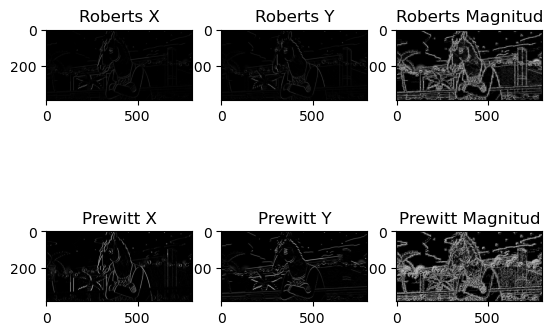

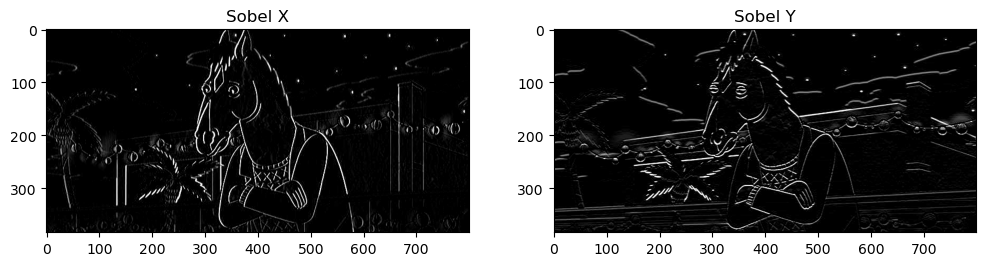

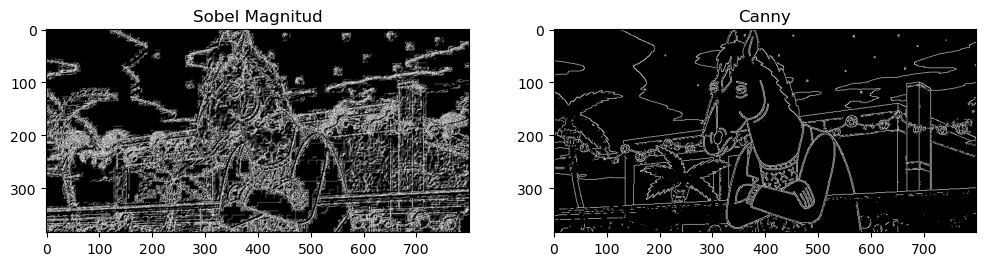

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
robertx = np.array([[-1, 0], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])
robx_img = cv2.filter2D(gray, -1, robertx)
roby_img = cv2.filter2D(gray, -1, roberty)
rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img) 

#prewit
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prex_img = cv2.filter2D(gray, -1, prewitt_x)
prey_img = cv2.filter2D(gray, -1, prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
prewitt_dir = np.arctan2(prey_img, prex_img)

#sobel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

cany_img = cv2.Canny(gray, 100, 100)


#mostrar en x, y y magnitud
plt.subplot(2, 3, 1), plt.imshow(robx_img, cmap='gray'), plt.title('Roberts X')
plt.subplot(2, 3, 2), plt.imshow(roby_img, cmap='gray'), plt.title('Roberts Y')
plt.subplot(2, 3, 3), plt.imshow(rob_grad, cmap='gray'), plt.title('Roberts Magnitud')
plt.subplot(2, 3, 4), plt.imshow(prex_img, cmap='gray'), plt.title('Prewitt X')
plt.subplot(2, 3, 5), plt.imshow(prey_img, cmap='gray'), plt.title('Prewitt Y')
plt.subplot(2, 3, 6), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt Magnitud')
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(sobelx_img, cmap='gray'), plt.title('Sobel X')
plt.subplot(1, 2, 2), plt.imshow(sobely_img, cmap='gray'), plt.title('Sobel Y')
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(sobel_mag, cmap='gray'), plt.title('Sobel Magnitud')
plt.subplot(1, 2, 2), plt.imshow(cany_img, cmap='gray'), plt.title('Canny')







SOLBEL

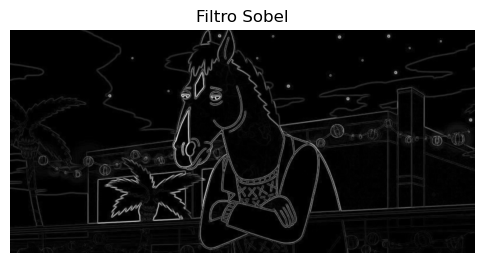

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX,cv2.CV_8U)
    return mag

img = cv2.imread('imagen1.jpg')
sobel_result = filtro_sobel(img)
plt.figure(figsize=(6, 6))
plt.imshow(sobel_result, cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()


Sobel Mejorado

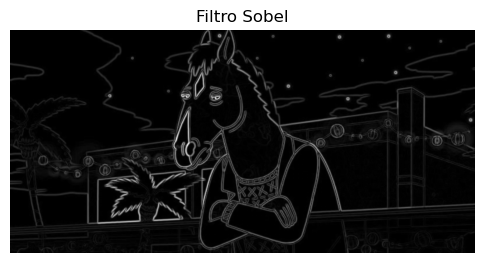

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gris = cv2.GaussianBlur(img_gris, (kernel_size, kernel_size), 0)


    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    #mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    #operacion morfologica
    kernel_m =np.ones((3, 3), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return mag

img = cv2.imread('imagen1.jpg')
sobel_result = filtro_sobel_mejorado(img)
plt.figure(figsize=(6, 6))
plt.imshow(sobel_result, cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()


robert

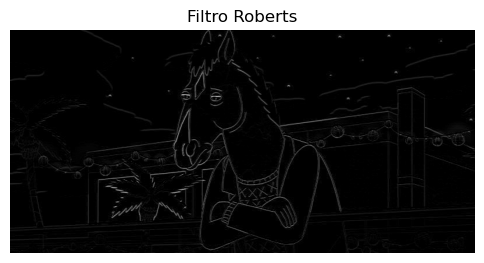

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array([[-1, 0], [0, 1]],dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]],dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('imagen1.jpg')
roberts_result = filtro_roberts(img)
plt.figure(figsize=(6, 6))
plt.imshow(roberts_result, cmap='gray')
plt.title('Filtro Roberts')
plt.axis('off')
plt.show()


Robert Mejorado

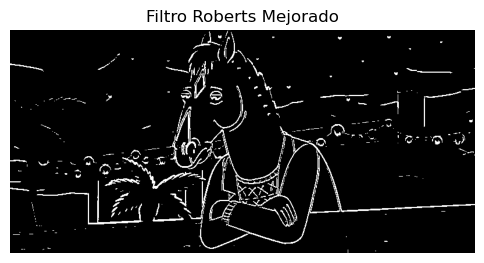

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suaviazar = cv2.GaussianBlur(img_gris, (3, 3), 0)
    robertx = np.array([[2, 0], [0, -2]],dtype=np.float32)
    roberty = np.array([[0, 2], [-2, 0]],dtype=np.float32)
    r_x = cv2.filter2D(suaviazar, -1, robertx)
    r_y = cv2.filter2D(suaviazar, -1, roberty)
    roberts = cv2.addWeighted(np.abs(r_x), 0.5, np.abs(r_y), 0.5, 0)
    _,bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    return bordes 

img = cv2.imread('imagen1.jpg')
roberts_result = filtro_roberts(img)
plt.figure(figsize=(6, 6))
plt.imshow(roberts_result, cmap='gray')
plt.title('Filtro Roberts Mejorado')
plt.axis('off')
plt.show()

Prewwit Mejorado

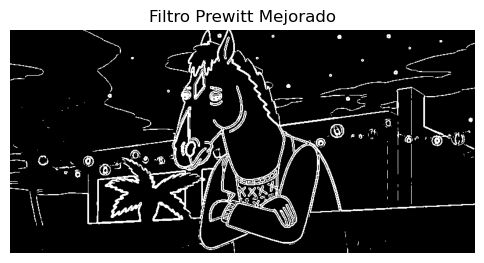

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_prewitt_mejorado(img):
    if img is None:
        raise ValueError("imagen no encontrada (cv2.imread devolvió None)")
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar = cv2.GaussianBlur(img_gris, (3, 3), 0)
    kernel_x = np.array([[-3, 0, 3], [-3, 0, 3], [-3, 0, 3]], dtype=np.float32)
    kernel_y = np.array([[-3, -3, -3], [0, 0, 0], [3, 3, 3]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizar, cv2.CV_64F, kernel_x)
    grad_y = cv2.filter2D(suavizar, cv2.CV_64F, kernel_y)
    magnitud = np.sqrt(grad_x**2 + grad_y**2)
    mag_u8 = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, bordes = cv2.threshold(mag_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bordes

img = cv2.imread('imagen1.jpg')
prewitt_result = filtro_prewitt_mejorado(img)
plt.figure(figsize=(6,6))
plt.imshow(prewitt_result, cmap='gray')
plt.axis('off')
plt.title('Filtro Prewitt Mejorado')
plt.show()

Canny

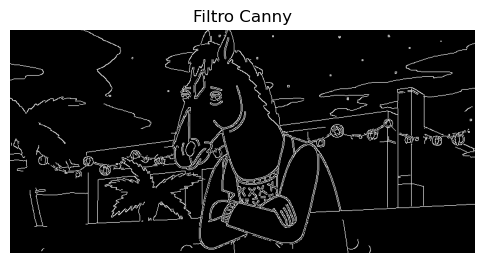

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_canny (img,umbral_baj0 = 100, umbral_alto = 200):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes = cv2.Canny(img_gris, umbral_baj0, umbral_alto)
    return bordes 

img = cv2.imread('imagen1.jpg')
canny_result = filtro_canny(img)
plt.figure(figsize=(6,6))
plt.imshow(canny_result, cmap='gray')
plt.axis('off')
plt.title('Filtro Canny')
plt.show()
